In [25]:
import pandas as pd 
import warnings 
warnings.filterwarnings(action="ignore")

In [4]:
cars_data = pd.read_csv("Cars.csv")
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [5]:
cars_data.shape

(81, 5)

In [8]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [9]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


##### Now lets check of Assumptions 

1. Linearity Test 

In [11]:
import seaborn as sns 
from matplotlib import pyplot as plt 

<Figure size 200x200 with 0 Axes>

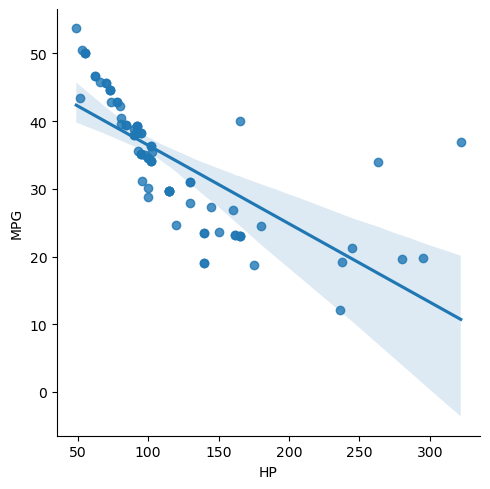

In [18]:
plt.figure(figsize=(2, 2))
sns.lmplot(data=cars_data, x="HP", y="MPG")

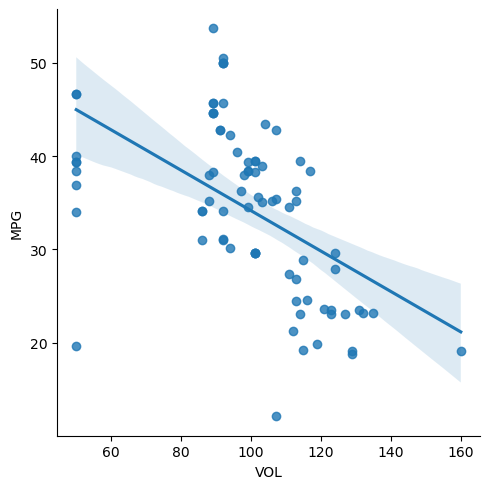

In [19]:
sns.lmplot(data=cars_data, x="VOL", y="MPG")

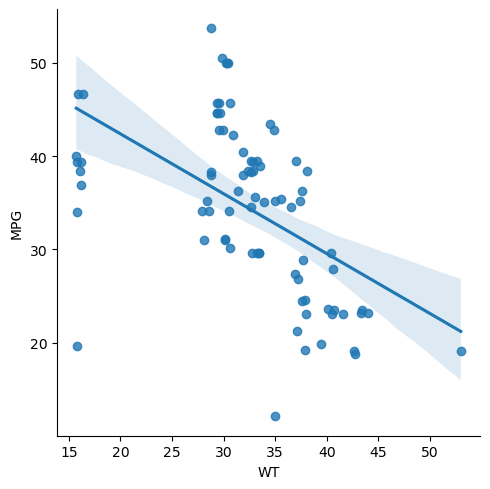

In [20]:
sns.lmplot(data=cars_data, x="WT", y="MPG")

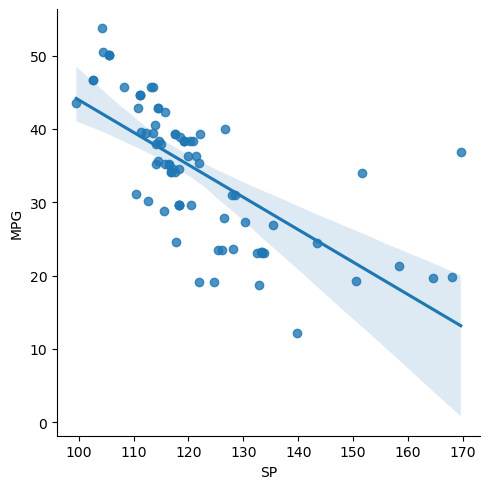

In [21]:
sns.lmplot(data=cars_data, x="SP", y="MPG")

##### 
2. Normality Test 

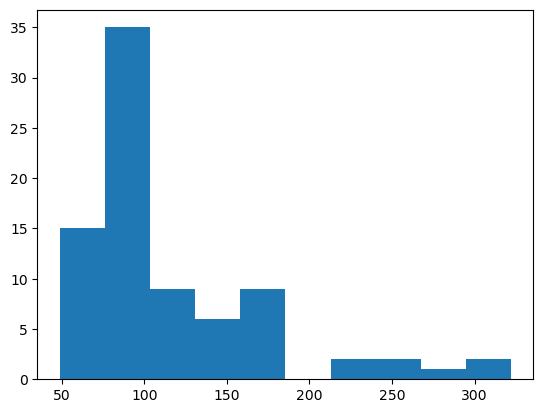

In [29]:
plt.hist(cars_data['HP'])

<function matplotlib.pyplot.show(close=None, block=None)>

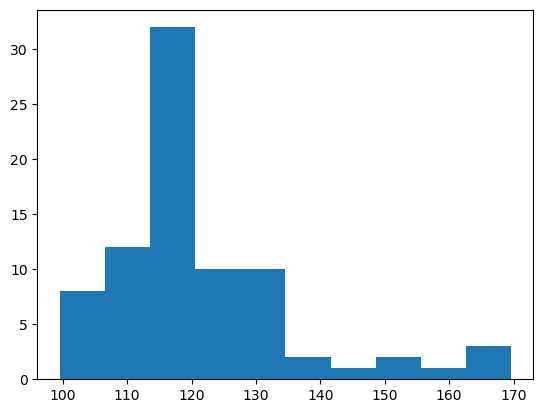

In [30]:
plt.hist(cars_data['SP'])
plt.show

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

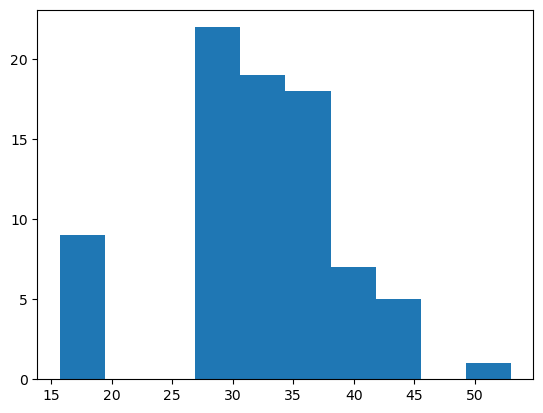

In [31]:
plt.hist(cars_data['WT'])

(array([ 1.,  6., 10.,  4., 10., 15., 17.,  8.,  5.,  5.]),
 array([12.10126289, 16.26120474, 20.42114659, 24.58108844, 28.74103029,
        32.90097213, 37.06091398, 41.22085583, 45.38079768, 49.54073953,
        53.70068138]),
 <BarContainer object of 10 artists>)

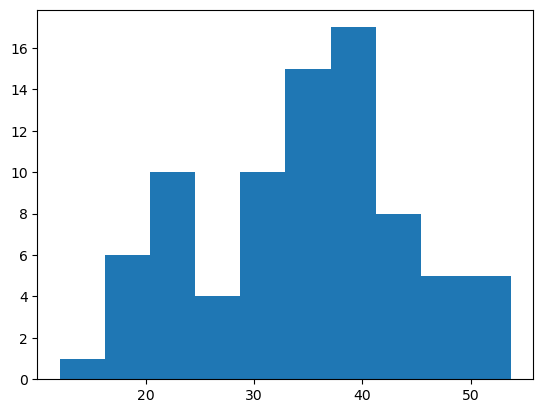

In [32]:
plt.hist(cars_data['MPG'])

##### 
3. Multi - correlation test 

In [35]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

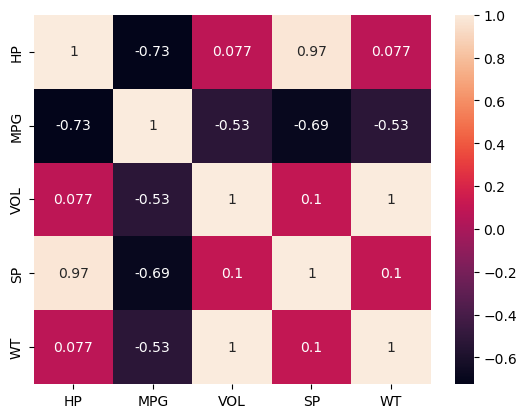

In [37]:
sns.heatmap(corr_matrix, annot=True)

##### 
4. AutoRegression Passed 

#####  Data Prepartion 
No need to do everything in INt and float

In [42]:
x = cars_data[['HP', 'VOL', 'SP', 'WT']]   ## input 
y = cars_data['MPG']                        ## output

### MODEL BUILDING & Training

In [38]:
from sklearn.linear_model import LinearRegression

In [44]:
linear_model  = LinearRegression()

In [45]:
linear_model.fit(x, y)

LinearRegression()

In [46]:
linear_model.intercept_

np.float64(30.677335852151842)

In [47]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

#### Model testing 

In [51]:
y_pred = linear_model.predict(x)
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

##### Model evaluation 

In [53]:
error = y - y_pred
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

#### Lets now perform Homoscedasticity test

In [55]:
cars_data['error_data'] = error

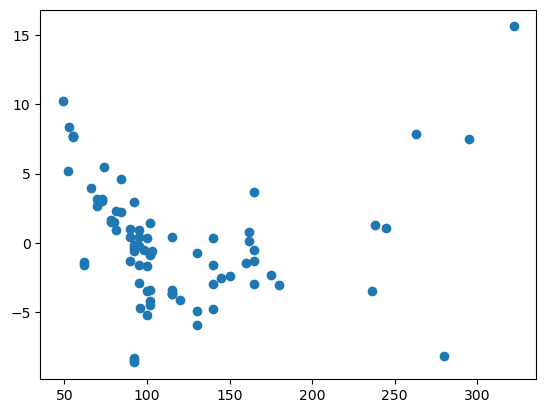

In [58]:
plt.scatter(data=cars_data, x='HP', y='error_data')

In [59]:
del cars_data['error_data']

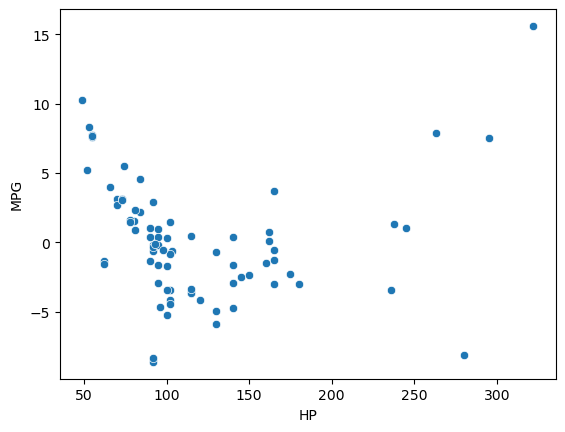

In [66]:
sns.scatterplot(data=cars_data, x = "HP", y=error)
plt.show()

### Zero residual mean test 

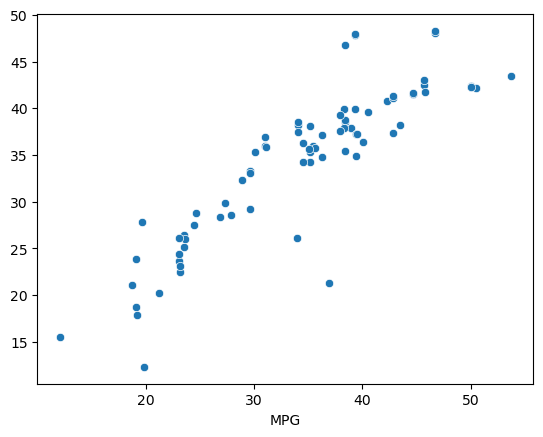

In [67]:
sns.scatterplot(x = cars_data['MPG'], y=y_pred)
plt.show()

##### All the test are failed 

### MODEL DEPLOYMENT

In [69]:
from pickle import dump 

In [70]:
dump(obj=linear_model, file=open(file= "linear_intelligence_file.pkl", mode='wb'))

In [71]:
### backend attachment 
from pickle import load 
linear_intel = load(file=open(file="linear_intelligence_file.pkl", mode='rb'))

In [72]:
linear_intel

LinearRegression()